In [1]:
# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

✅ Loaded df_base (9,000,000 rows)
✅ Loaded df_rep  (588,000 rows)
Detected genes: ['gene_1', 'gene_2']


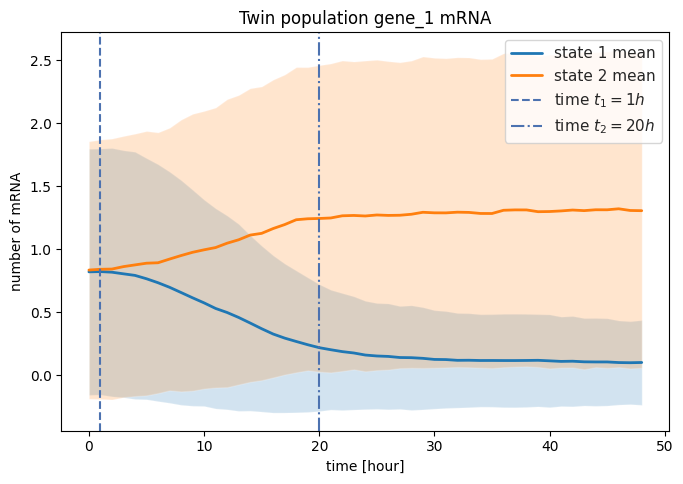

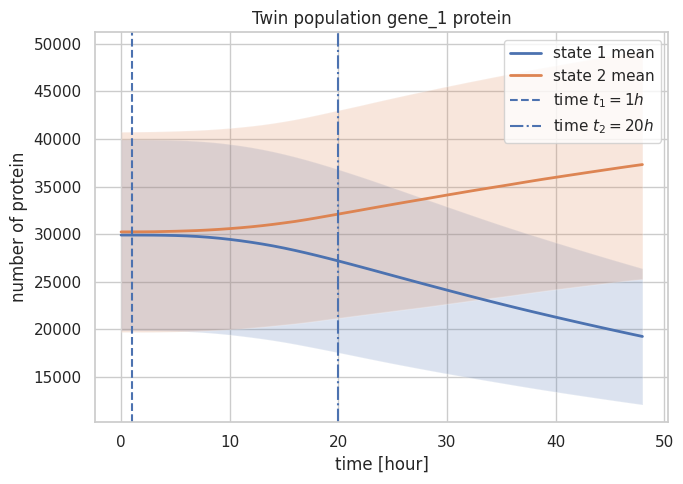

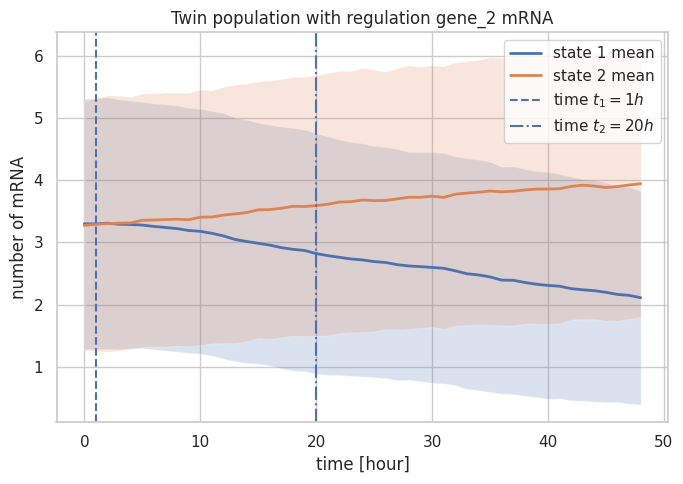

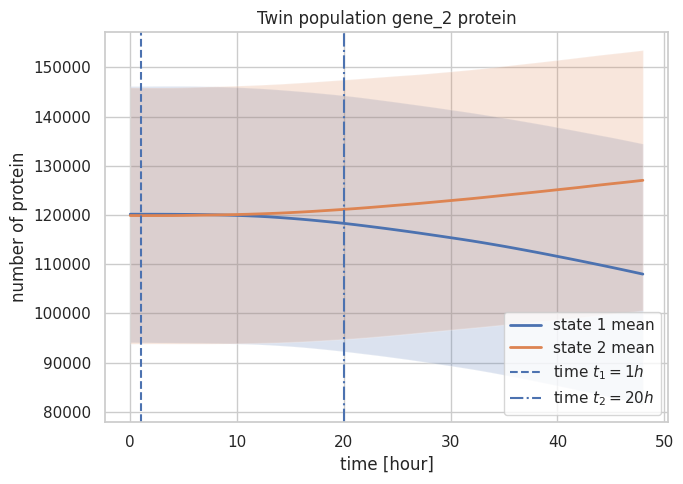

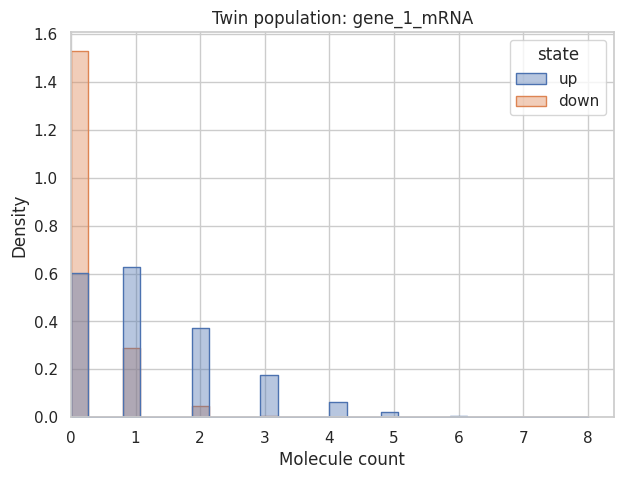

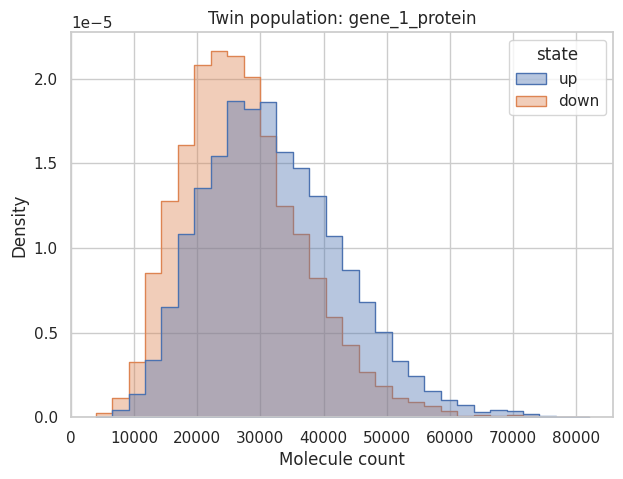

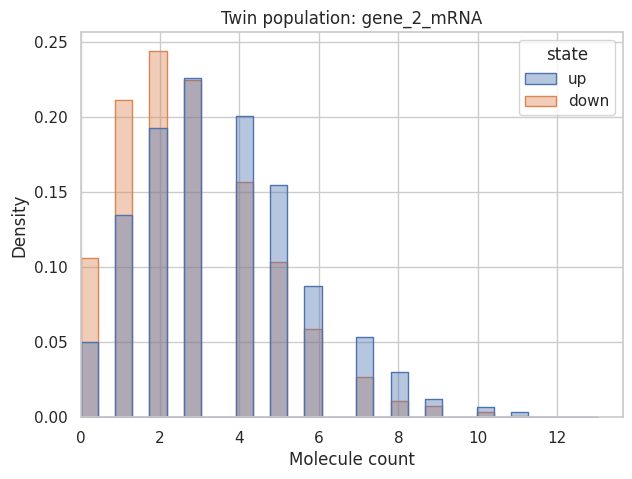

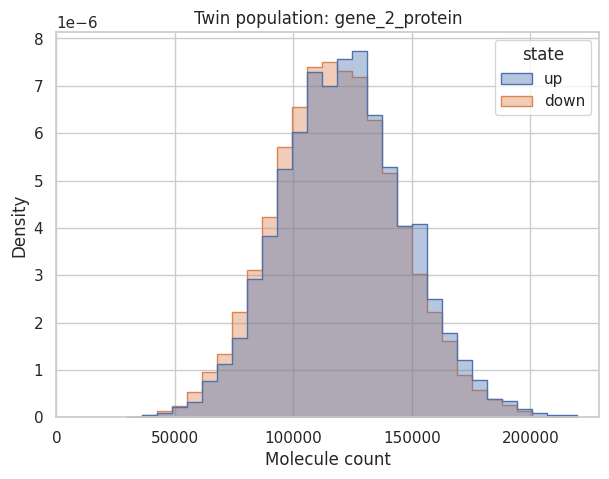

In [3]:
# === CONFIGURATION ===
twin_csv = Path("/projects/b1042/GoyalLab/jaekj/TWINFER/TwINFER/grnInference/simulation_data/drift_simulation/drift_simulation_0_15h/df_rows_0_0_1_15012026_095253_ncells_6000_2_states_d8b80148.csv")
base_csv = Path("/projects/b1042/GoyalLab/jaekj/TWINFER/TwINFER/grnInference/simulation_data/drift_simulation/drift_simulation_0_15h/simulation_before_division_df_rows_0_0_1_15012026_095253_ncells_6000_2_states_d8b80148.csv")

# %%
# === LOAD ===
df_base = pd.read_csv(base_csv)
df_rep = pd.read_csv(twin_csv)
print(f"✅ Loaded df_base ({len(df_base):,} rows)")
print(f"✅ Loaded df_rep  ({len(df_rep):,} rows)")

# Sanity check for state column
if "state" not in df_rep.columns:
    raise ValueError("No 'state' column found in df_rep — did you add it in process_param_set()?")

# Infer states for df_base if missing (optional)
if "state" not in df_base.columns:
    n_cells_half = df_rep["clone_id"].nunique() // 2
    df_base["state"] = ["up"] * n_cells_half + ["down"] * n_cells_half

# %%
# === DETECT GENES ===
mrna_cols = [c for c in df_rep.columns if c.endswith("_mRNA")]
protein_cols = [c for c in df_rep.columns if c.endswith("_protein")]
genes = sorted({c.split("_")[0] + "_" + c.split("_")[1] for c in protein_cols})
print(f"Detected genes: {genes}")

# %%
def plot_state_dynamics(df, gene, kind="protein", title_prefix=""):
    """
    Plot mean ± SD over time for 'up' and 'down' states for a given gene.
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.set(style="whitegrid")
    label_dict_state = {"up": "state 2", "down": "state 1"}
    label_dict = {"gene_1": "X", "gene_2": "Y"}
    for state, subdf in df.groupby("state"):
        cols = [c for c in subdf.columns if c.endswith(f"{gene}_{kind}")]
        if not cols:
            continue

        grouped = subdf.groupby("time_step")[cols]
        mean = grouped.mean().values.flatten()
        std = grouped.std().values.flatten()
        times = grouped.mean().index
        ax.plot(times, mean, label=f"{label_dict_state[state]} mean", lw=2)
        ax.fill_between(times, mean - std, mean + std, alpha=0.2)
    plt.axvline(1, linestyle = "--", label = r"time $t_1 = 1h$")
    plt.axvline(20, linestyle = "-.", label = r"time $t_2 = 20h$")
    ax.set_title(f"{title_prefix} {gene} {kind}")
    ax.set_xlabel("time [hour]")
    ax.set_ylabel(f"number of {kind}")
    ax.legend()
    plt.tight_layout()
    plt.show()

# %%
# === PLOT PARENT POPULATION (df_base) ===
gene_to_plot = "gene_1"

# %%
# === PLOT TWIN POPULATION (df_rep) ===
plot_state_dynamics(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_state_dynamics(df_rep, gene_to_plot, "protein", "Twin population")

# === PLOT PARENT POPULATION (df_base) ===
gene_to_plot = "gene_2"

# %%
# === PLOT TWIN POPULATION (df_rep) ===
plot_state_dynamics(df_rep, gene_to_plot, "mRNA", "Twin population with regulation")
plot_state_dynamics(df_rep, gene_to_plot, "protein", "Twin population")

# %%
# === COMPARE FINAL DISTRIBUTIONS ===
def plot_final_distribution_by_state(df, gene, kind="protein", title="Final distribution"):
    import seaborn as sns
    import matplotlib.pyplot as plt

    t_max = 20
    col = f"{gene}_{kind}"

    plt.figure(figsize=(7,5))
    sns.histplot(
        data=df[df["time_step"] == t_max],
        x=col,
        hue="state",
        bins=30,                # adjust number of bins as needed
        multiple="layer",       # or "dodge" to see side-by-side bars
        stat="density",         # normalizes area to 1
        fill=True,
        alpha=0.4,
        element="step"          # outlines instead of solid bars
    )
    
    plt.title(f"{title}: {col}")
    plt.xlabel("Molecule count")
    plt.xlim(left=0)
    plt.show()

gene_to_plot = "gene_1"
plot_final_distribution_by_state(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_final_distribution_by_state(df_rep, gene_to_plot, "protein", "Twin population")
gene_to_plot = "gene_2"
plot_final_distribution_by_state(df_rep, gene_to_plot, "mRNA", "Twin population")
plot_final_distribution_by_state(df_rep, gene_to_plot, "protein", "Twin population")


/tmp/ipykernel_2382030/3619962096.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation
/tmp/ipykernel_2382030/3619962096.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation
/tmp/ipykernel_2382030/3619962096.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation
/tmp/ipykernel_2382030/3619962096.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation


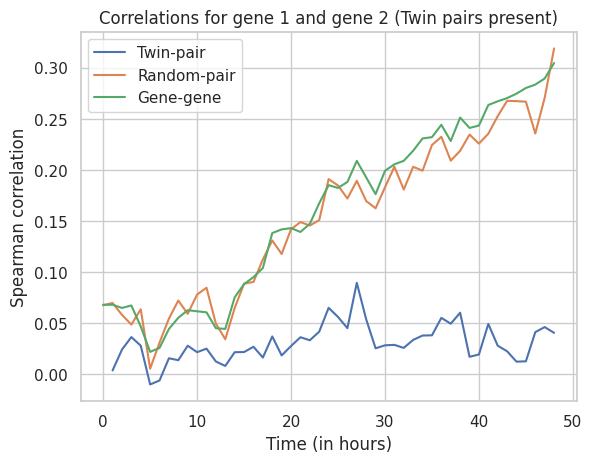

In [4]:
from scipy.stats import spearmanr
time_points = df_rep['time_step'].unique()
n_genes = 2

gene_list = [f"gene_{i}" for i in range(1, n_genes + 1)]
columns_interest = [f"{gene}_mRNA" for gene in gene_list]
corr_list = []
rand_corr_list = []
gene_corr = []
# ----- Step 1: Compute correlations -----
def calculate_correlation(rep_0, rep_1):
    correlations = {}
    for gene_1 in gene_list:
        for gene_2 in gene_list:
            delta_1 = rep_0[f"{gene_1}_mRNA"] - rep_1[f"{gene_1}_mRNA"]
            delta_2 = rep_0[f"{gene_2}_mRNA"] - rep_1[f"{gene_2}_mRNA"]
            corr = spearmanr(delta_1, delta_2).correlation
            correlations[f"{gene_1}-{gene_2}"] = corr
    return correlations

# ----- Step 2: Convert to matrix -----
def dict_to_matrix(correlation_dict, gene_list):
    matrix = pd.DataFrame(index=gene_list, columns=gene_list, dtype=float)
    for key, value in correlation_dict.items():
        g1, g2 = key.split("-")
        matrix.loc[g1, g2] = value
    return matrix
clone_id = pd.Series(df_rep['clone_id'].unique()).sample(frac=0.5, random_state=42)

for time in time_points:
    # if time > 1500:
    #     continue
    # Assume updated_df is already defined and contains 'replicate', 'timestep', and mRNA columns
    singleTime_df = df_rep[df_rep['time_step'] == time]
    singleTime_df = singleTime_df[singleTime_df['clone_id'].isin(clone_id)]
    gene_gene_corr = spearmanr(singleTime_df['gene_1_mRNA'], singleTime_df['gene_2_mRNA']).correlation
    # Split into replicates
    rep_0_t1 = singleTime_df[singleTime_df['replicate'] == 1].reset_index(drop=True)
    rep_1_t1 = singleTime_df[singleTime_df['replicate'] == 2].reset_index(drop=True)
    rep_shuffled_t1 = rep_1_t1.sample(frac = 1).reset_index(drop=True)


    # Compute correlation matrix
    correlation_dict = calculate_correlation(rep_0_t1, rep_1_t1)
    corr_rand_dict = calculate_correlation(rep_0_t1, rep_shuffled_t1)
    corr_list.append(correlation_dict['gene_1-gene_2'])
    rand_corr_list.append(corr_rand_dict['gene_1-gene_2'])
    gene_corr.append(gene_gene_corr)

plt.title("Correlations for gene 1 and gene 2 (Twin pairs present)")
plt.plot(time_points, corr_list, label = "Twin-pair")
plt.plot(time_points, rand_corr_list, label = "Random-pair")
plt.plot(time_points, gene_corr, label="Gene-gene")
plt.xlabel('Time (in hours)')
plt.ylabel('Spearman correlation')
# plt.axhline(0.01, linestyle = "--",  color = "red",label = "twin threshold")
# plt.axhline(-0.01, linestyle = "--",  color = "red",)

# plt.axhline(0.05, linestyle = "--", color = "blue", label = "gene-gene threshold")
# plt.axhline(-0.05, linestyle = "--", color = "blue",)
plt.legend()
plt.show()


/tmp/ipykernel_2382030/1176381374.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation
/tmp/ipykernel_2382030/1176381374.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation
/tmp/ipykernel_2382030/1176381374.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation
/tmp/ipykernel_2382030/1176381374.py:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr = spearmanr(delta_1, delta_2).correlation


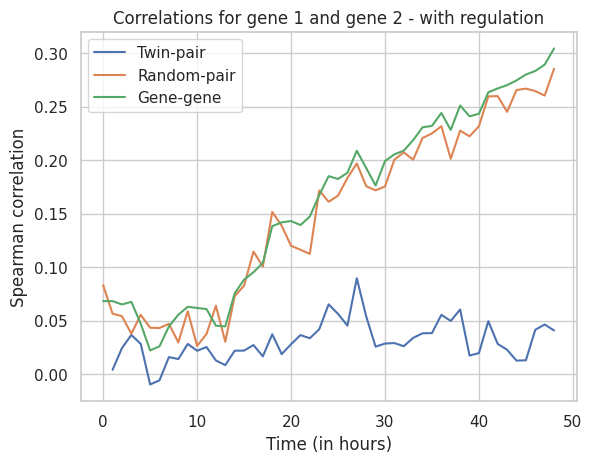

In [5]:
from scipy.stats import spearmanr
time_points = df_rep['time_step'].unique()
n_genes = 2

gene_list = [f"gene_{i}" for i in range(1, n_genes + 1)]
columns_interest = [f"{gene}_mRNA" for gene in gene_list]
corr_list = []
rand_corr_list = []
gene_corr = []
# ----- Step 1: Compute correlations -----
def calculate_correlation(rep_0, rep_1):
    correlations = {}
    for gene_1 in gene_list:
        for gene_2 in gene_list:
            delta_1 = rep_0[f"{gene_1}_mRNA"] - rep_1[f"{gene_1}_mRNA"]
            delta_2 = rep_0[f"{gene_2}_mRNA"] - rep_1[f"{gene_2}_mRNA"]
            corr = spearmanr(delta_1, delta_2).correlation
            correlations[f"{gene_1}-{gene_2}"] = corr
    return correlations

# ----- Step 2: Convert to matrix -----
def dict_to_matrix(correlation_dict, gene_list):
    matrix = pd.DataFrame(index=gene_list, columns=gene_list, dtype=float)
    for key, value in correlation_dict.items():
        g1, g2 = key.split("-")
        matrix.loc[g1, g2] = value
    return matrix
clone_id = pd.Series(df_rep['clone_id'].unique()).sample(frac=0.5, random_state=42)

for time in time_points:
    # if time > 1500:
    #     continue
    # Assume updated_df is already defined and contains 'replicate', 'timestep', and mRNA columns
    singleTime_df = df_rep[df_rep['time_step'] == time]
    singleTime_df = singleTime_df[singleTime_df['clone_id'].isin(clone_id)]
    gene_gene_corr = spearmanr(singleTime_df['gene_1_mRNA'], singleTime_df['gene_2_mRNA']).correlation
    # Split into replicates
    rep_0_t1 = singleTime_df[singleTime_df['replicate'] == 1].reset_index(drop=True)
    rep_1_t1 = singleTime_df[singleTime_df['replicate'] == 2].reset_index(drop=True)
    rep_shuffled_t1 = rep_1_t1.sample(frac = 1).reset_index(drop=True)


    # Compute correlation matrix
    correlation_dict = calculate_correlation(rep_0_t1, rep_1_t1)
    corr_rand_dict = calculate_correlation(rep_0_t1, rep_shuffled_t1)
    corr_list.append(correlation_dict['gene_1-gene_2'])
    rand_corr_list.append(corr_rand_dict['gene_1-gene_2'])
    gene_corr.append(gene_gene_corr)

plt.title("Correlations for gene 1 and gene 2 - with regulation")
plt.plot(time_points, corr_list, label = "Twin-pair")
plt.plot(time_points, rand_corr_list, label = "Random-pair")
plt.plot(time_points, gene_corr, label="Gene-gene")
plt.xlabel('Time (in hours)')
plt.ylabel('Spearman correlation')
# plt.axhline(0.0, linestyle = "--",  color = "red",label = "twin threshold")
# plt.axhline(-0.01, linestyle = "--",  color = "red",)

# plt.axhline(0.05, linestyle = "--", color = "blue", label = "gene-gene threshold")
# plt.axhline(-0.05, linestyle = "--", color = "blue",)
plt.legend()
plt.show()


## Extended fig E8

In [6]:
def aggregate_corr_across_replicates(
    dfs,
    corr_func,
    **kwargs
):
    corr_series = []

    for df in dfs:
        cdf = corr_func(df, **kwargs)
        corr_series.append(cdf.set_index("time_step")["corr"])

    mat = pd.concat(corr_series, axis=1)

    return pd.DataFrame({
        "time_step": mat.index,
        "mean": mat.mean(axis=1),
        "std": mat.std(axis=1)
    })

def population_gene_gene_corr_over_time(df, gene_A, gene_B, kind="protein"):
    col_A = f"{gene_A}_{kind}"
    col_B = f"{gene_B}_{kind}"

    records = []

    for t, tdf in df.groupby("time_step"):
        if len(tdf) < 10:
            continue

        rho, _ = spearmanr(tdf[col_A], tdf[col_B])
        records.append((t, rho))

    return pd.DataFrame(records, columns=["time_step", "corr"])

from scipy.stats import spearmanr
import pandas as pd
import numpy as np

def twin_gene_gene_corr_over_time(df, gene_A, gene_B, kind="protein"):
    col_A = f"{gene_A}_{kind}"
    col_B = f"{gene_B}_{kind}"

    records = []

    for t, tdf in df.groupby("time_step"):
        A_vals, B_vals = [], []

        for _, cdf in tdf.groupby("clone_id"):
            if len(cdf) != 2:
                continue
            A_vals.extend(cdf[col_A].values)
            B_vals.extend(cdf[col_B].values)

        if len(A_vals) < 10:
            continue

        rho, _ = spearmanr(A_vals, B_vals)
        records.append((t, rho))

    return pd.DataFrame(records, columns=["time_step", "corr"])


In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

def load_replicates(folder, pattern="*.csv"):
    files = sorted(Path(folder).glob(pattern))
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df["replicate"] = f.stem
        dfs.append(df)
    print(f"Loaded {len(dfs)} replicates from {folder}")
    return dfs


In [8]:
import matplotlib.pyplot as plt

def plot_gene_gene_corr_triplet(
    agg_twin,
    agg_random,
    agg_pop,
    gene_A,
    gene_B,
    kind="protein",
    title_suffix=""
):
    fig, ax = plt.subplots(figsize=(7, 5))

    for agg, label, ls in [
        (agg_twin,   "Twin",   "-"),
        (agg_random, "Random", "--"),
        (agg_pop,    "Population", ":")
    ]:
        ax.plot(agg["time_step"], agg["mean"], lw=2, ls=ls, label=label)
        ax.fill_between(
            agg["time_step"],
            agg["mean"] - agg["std"],
            agg["mean"] + agg["std"],
            alpha=0.25
        )

    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Spearman ρ")
    ax.set_title(
        f"{gene_A} vs {gene_B} ({kind}) {title_suffix}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()


In [9]:
gene_A = "gene_1"
gene_B = "gene_2"
base_folder = Path("/projects/b1042/GoyalLab/jaekj/TWINFER/TwINFER/grnInference/simulation_data/drift_simulation/drift_simulation_0_15h/")
dfs_no_reg = [
    pd.read_csv(f)
    for f in sorted(base_folder.glob("df*no_reg*.csv"))
]

# --- REGULATION ---
dfs_reg = [
    pd.read_csv(f)
    for f in sorted(base_folder.glob("df*.csv"))
    if "no_reg" not in f.name
]


In [13]:
no_reg_files

[]

Streaming replicates: 0it [00:00, ?it/s]
Streaming replicates:   0%|          | 0/9 [00:00<?, ?it/s]/tmp/ipykernel_2382030/2772333428.py:68: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x, y).correlation
Streaming replicates:  11%|█         | 1/9 [00:07<00:58,  7.25s/it]/tmp/ipykernel_2382030/2772333428.py:68: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x, y).correlation
Streaming replicates:  22%|██▏       | 2/9 [00:14<00:50,  7.21s/it]/tmp/ipykernel_2382030/2772333428.py:68: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x, y).correlation
Streaming replicates:  33%|███▎      | 3/9 [00:21<00:42,  7.03s/it]/tmp/ipykernel_2382030/2772333428.py:68: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(x, y).correlation
Streaming r

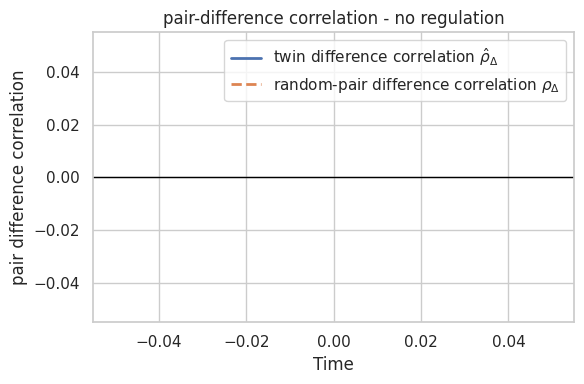

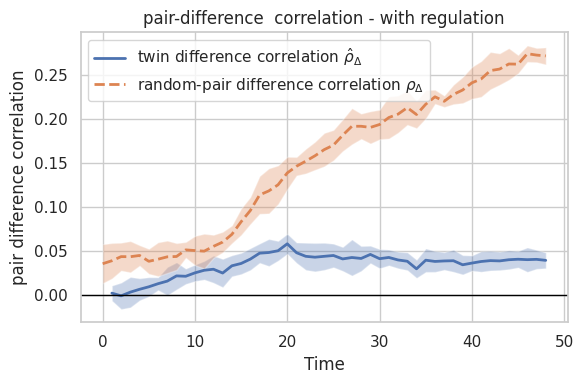

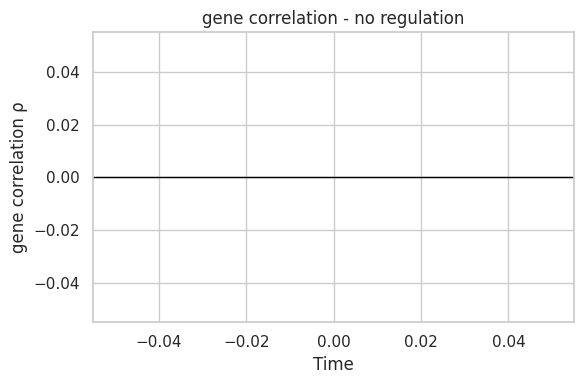

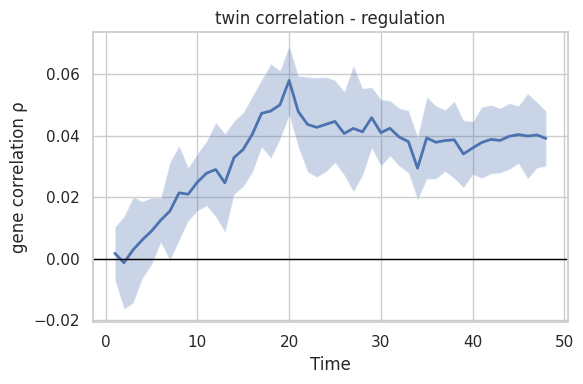

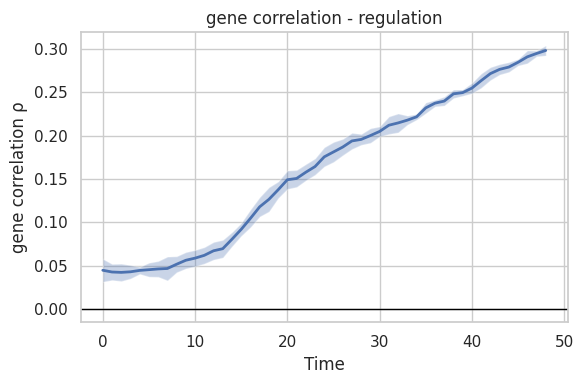

In [12]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ======================================================
# CONFIG
# ======================================================
DATA_FOLDER = Path(
    "/projects/b1042/GoyalLab/jaekj/TWINFER/TwINFER/grnInference/simulation_data/drift_simulation/drift_simulation_0_15h"
)

GENE_A = "gene_1"
GENE_B = "gene_2"
KIND   = "mRNA"        # or "protein"

RANDOM_FRAC = 0.5
RANDOM_SEED = 42
MIN_PAIRS = 10

# ======================================================
# LOW-LEVEL HELPERS
# ======================================================
def get_twin_pairs_by_time(df):
    """Return dict: time -> (rep0, rep1) for true twins."""
    out = {}
    for t, tdf in df.groupby("time_step"):
        twins = (
            tdf.groupby("clone_id")
               .filter(lambda x: len(x) == 2)
               .sort_values("clone_id")
        )
        if len(twins) == 0:
            continue

        rep0 = twins.groupby("clone_id").nth(0)
        rep1 = twins.groupby("clone_id").nth(1)
        out[t] = (rep0, rep1)
    return out


def get_random_pairs_by_time(df, frac=0.5, seed=42):
    """Return dict: time -> (rep0, rep1) for random pairs."""
    rng = np.random.default_rng(seed)
    out = {}

    for t, tdf in df.groupby("time_step"):
        shuffled = tdf.sample(frac=1, random_state=seed)
        n = int(len(shuffled) * frac)
        n = (n // 2) * 2  # even
        if n < 2:
            continue

        s = shuffled.iloc[:n]
        rep0 = s.iloc[::2]
        rep1 = s.iloc[1::2]
        out[t] = (rep0, rep1)

    return out


def spearman_safe(x, y):
    if len(x) < MIN_PAIRS:
        return np.nan
    return spearmanr(x, y).correlation

# ======================================================
# PROCESS ONE REPLICATE
# ======================================================
def process_replicate(df):
    """
    Compute ALL metrics for ONE replicate.
    Returns dict of DataFrames keyed by metric name.
    """
    colA = f"{GENE_A}_{KIND}"
    colB = f"{GENE_B}_{KIND}"

    records = {
        "delta_twin": [],
        "delta_rand": [],
        "gene": [],
        "gene_rand": [],
    }

    # --- Δ-based ---
    twin_pairs = get_twin_pairs_by_time(df)
    rand_pairs = get_random_pairs_by_time(df, RANDOM_FRAC, RANDOM_SEED)

    for t in sorted(set(twin_pairs) | set(rand_pairs)):
        # Δ twin
        if t in twin_pairs:
            r0, r1 = twin_pairs[t]
            dA = r0[colA].values - r1[colA].values
            dB = r0[colB].values - r1[colB].values
            records["delta_twin"].append((t, spearman_safe(dA, dB)))

        # Δ random
        if t in rand_pairs:
            r0, r1 = rand_pairs[t]
            dA = r0[colA].values - r1[colA].values
            dB = r0[colB].values - r1[colB].values
            records["delta_rand"].append((t, spearman_safe(dA, dB)))

    # --- Gene–gene (population) ---
    rng = np.random.default_rng(RANDOM_SEED)
    for t, tdf in df.groupby("time_step"):
        A = tdf[colA].values
        B = tdf[colB].values

        records["gene"].append((t, spearman_safe(A, B)))
        records["gene_rand"].append((t, spearman_safe(A, rng.permutation(B))))

    return {
        k: pd.DataFrame(v, columns=["time", "corr"]).dropna()
        for k, v in records.items()
    }

# ======================================================
# STREAMING AGGREGATION
# ======================================================
def stream_aggregate(files):
    acc = {
        "delta_twin": defaultdict(list),
        "delta_rand": defaultdict(list),
        "gene": defaultdict(list),
        "gene_rand": defaultdict(list),
    }

    for f in tqdm(files, desc="Streaming replicates"):
        df = pd.read_csv(f)

        result = process_replicate(df)

        for key, df_corr in result.items():
            for _, r in df_corr.iterrows():
                acc[key][r["time"]].append(r["corr"])

        del df  # free memory

    # convert to mean ± std
    out = {}
    for key, d in acc.items():
        times = sorted(d.keys())
        out[key] = pd.DataFrame({
            "time": times,
            "mean": [np.mean(d[t]) for t in times],
            "std":  [np.std(d[t])  for t in times],
        })

    return out

# ======================================================
# PLOTTING
# ======================================================
def plot_mean_std(main, null, title):
    plt.figure(figsize=(6, 4))
    plt.plot(main["time"], main["mean"], lw=2, label=r"twin difference correlation $\hat{\rho}_\Delta$")
    plt.fill_between(
        main["time"],
        main["mean"] - main["std"],
        main["mean"] + main["std"],
        alpha=0.3
    )

    plt.plot(null["time"], null["mean"], lw=2, ls="--", label=r"random-pair difference correlation $\rho_\Delta$")
    plt.fill_between(
        null["time"],
        null["mean"] - null["std"],
        null["mean"] + null["std"],
        alpha=0.3
    )

    plt.axhline(0, color="black", lw=1)
    plt.xlabel("Time")
    plt.ylabel("pair difference correlation")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ======================================================
# RUN
# ======================================================
no_reg_files = [f for f in DATA_FOLDER.glob("df*no_reg*.csv")]
if len(no_reg_files) > 20:
    no_reg_files = no_reg_files[:20]
reg_files    = [f for f in DATA_FOLDER.glob("df*.csv") if "no_reg" not in f.name]
if len(reg_files) > 20:
    reg_files = reg_files[:20]

no_reg = stream_aggregate(no_reg_files)
reg    = stream_aggregate(reg_files)

def plot_mean_std_single(agg, title):
    plt.figure(figsize=(6, 4))
    plt.plot(agg["time"], agg["mean"], lw=2)
    plt.fill_between(
        agg["time"],
        agg["mean"] - agg["std"],
        agg["mean"] + agg["std"],
        alpha=0.3
    )

    plt.axhline(0, color="black", lw=1)
    plt.xlabel("Time")
    plt.ylabel("gene correlation ρ")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# ---- FINAL 4 PLOTS ----
# ---- FINAL 4 PLOTS ----

# Δ-based: twin vs random
plot_mean_std(
    no_reg["delta_twin"],
    no_reg["delta_rand"],
    "pair-difference correlation - no regulation"
)

plot_mean_std(
    reg["delta_twin"],
    reg["delta_rand"],
    "pair-difference  correlation - with regulation"
)

# Gene–gene: real only
plot_mean_std_single(
    no_reg["gene"],
    "gene correlation - no regulation"
)
plot_mean_std_single(
    reg["delta_twin"],
    "twin correlation - regulation"
)

plot_mean_std_single(
    reg["gene"],
    "gene correlation - regulation"
)


Streaming replicates: 100%|██████████| 20/20 [00:39<00:00,  1.98s/it]


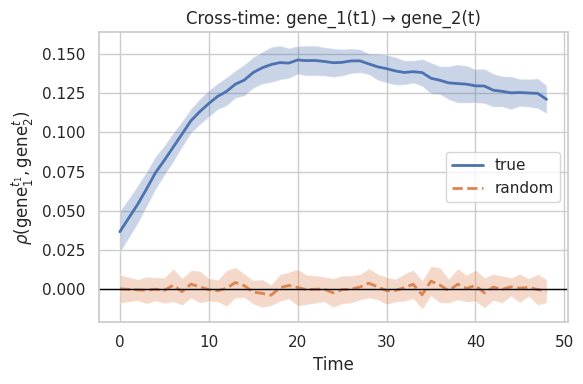

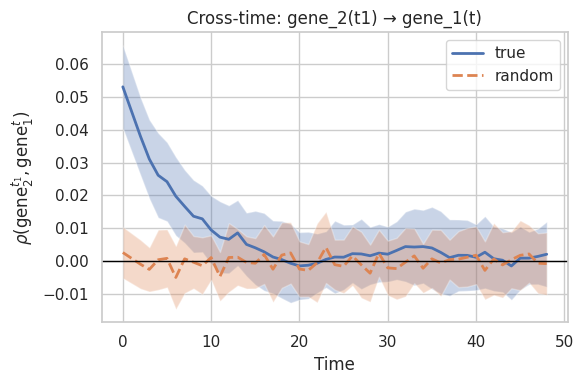

In [8]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt

# ======================================================
# CONFIG
# ======================================================
DATA_FOLDER = Path(
    "/home/gzu5140/Keerthana_b1042/grnInference/simulation_data/"
    "drift_simulation/drift_simulation_0_15h"
)

GENE_A = "gene_1"
GENE_B = "gene_2"
KIND   = "mRNA"          # or "protein"

REFERENCE_TIME = 1
MIN_PAIRS = 10
RANDOM_SEED = 42

# ======================================================
# HELPERS
# ======================================================
def spearman_safe(x, y):
    if len(x) < MIN_PAIRS:
        return np.nan
    return spearmanr(x, y).correlation


def get_matched_clones(df, t0, t):
    """
    Return two DataFrames (df_t0, df_t) indexed by clone_id,
    restricted to clones present at both times.
    """
    df0 = df[df["time_step"] == t0].set_index("clone_id")
    dft = df[df["time_step"] == t].set_index("clone_id")

    common = df0.index.intersection(dft.index)
    if len(common) < MIN_PAIRS:
        return None

    return df0.loc[common], dft.loc[common]

# ======================================================
# PROCESS ONE REPLICATE
# ======================================================
def process_replicate_cross_time(df):
    colA = f"{GENE_A}_{KIND}"
    colB = f"{GENE_B}_{KIND}"

    records = {
        "A_to_B": [],
        "B_to_A": [],
        "A_to_B_rand": [],
        "B_to_A_rand": [],
    }

    rng = np.random.default_rng(RANDOM_SEED)

    times = sorted(df["time_step"].unique())
    times = [t for t in times if t != REFERENCE_TIME]

    for t in times:
        matched = get_matched_clones(df, REFERENCE_TIME, t)
        if matched is None:
            continue

        df0, dft = matched

        A0 = df0[colA].values
        B0 = df0[colB].values
        At = dft[colA].values
        Bt = dft[colB].values

        # --- true cross-time correlations ---
        records["A_to_B"].append((t, spearman_safe(A0, Bt)))
        records["B_to_A"].append((t, spearman_safe(B0, At)))

        # --- permutation null (break clone matching at time t) ---
        perm = rng.permutation(len(Bt))
        records["A_to_B_rand"].append((t, spearman_safe(A0, Bt[perm])))
        records["B_to_A_rand"].append((t, spearman_safe(B0, At[perm])))

    return {
        k: pd.DataFrame(v, columns=["time", "corr"]).dropna()
        for k, v in records.items()
    }

# ======================================================
# STREAMING AGGREGATION
# ======================================================
def stream_aggregate_cross_time(files):
    acc = {
        "A_to_B": defaultdict(list),
        "B_to_A": defaultdict(list),
        "A_to_B_rand": defaultdict(list),
        "B_to_A_rand": defaultdict(list),
    }

    for f in tqdm(files, desc="Streaming replicates"):
        df = pd.read_csv(f)
        result = process_replicate_cross_time(df)

        for key, df_corr in result.items():
            for _, r in df_corr.iterrows():
                acc[key][r["time"]].append(r["corr"])

        del df

    out = {}
    for key, d in acc.items():
        times = sorted(d.keys())
        out[key] = pd.DataFrame({
            "time": times,
            "mean": [np.mean(d[t]) for t in times],
            "std":  [np.std(d[t])  for t in times],
        })

    return out

# ======================================================
# PLOTTING
# ======================================================
def plot_cross_time(main, null, title, ylabel):
    plt.figure(figsize=(6, 4))

    plt.plot(main["time"], main["mean"], lw=2, label="true")
    plt.fill_between(
        main["time"],
        main["mean"] - main["std"],
        main["mean"] + main["std"],
        alpha=0.3
    )

    plt.plot(null["time"], null["mean"], lw=2, ls="--", label="random")
    plt.fill_between(
        null["time"],
        null["mean"] - null["std"],
        null["mean"] + null["std"],
        alpha=0.3
    )

    plt.axhline(0, color="black", lw=1)
    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ======================================================
# RUN
# ======================================================
files    = [f for f in DATA_FOLDER.glob("df*.csv") if "no_reg" not in f.name and "30102025" not in f.name]
if len(files) > 20:
    files = files[:20]

agg = stream_aggregate_cross_time(files)

plot_cross_time(
    agg["A_to_B"],
    agg["A_to_B_rand"],
    "Cross-time: gene_1(t1) → gene_2(t)",
    r"$\rho(\mathrm{gene}_1^{t_1}, \mathrm{gene}_2^{t})$"
)

plot_cross_time(
    agg["B_to_A"],
    agg["B_to_A_rand"],
    "Cross-time: gene_2(t1) → gene_1(t)",
    r"$\rho(\mathrm{gene}_2^{t_1}, \mathrm{gene}_1^{t})$"
)


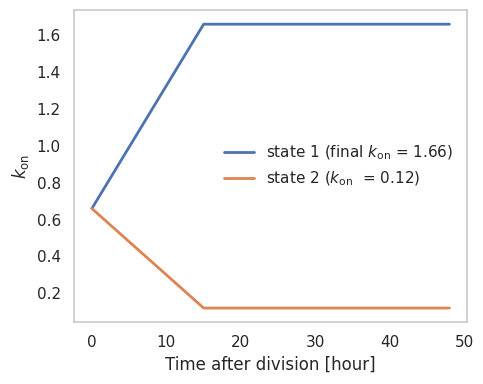

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# time after division (hours)
t = np.linspace(0, 48, 500)

# parameters (same as your simulation)
t_start = 1500
tau = 15
t_offset = 1500

final_up = 1.66
final_down = 0.12

# global time
t_global = t + t_offset

# scaling factors
scale_up = np.ones_like(t)
scale_down = np.ones_like(t)

ramp = (t_global >= t_start) & (t_global < t_start + tau)
after = t_global >= t_start + tau

initial = 0.66

scale_up[ramp] =  initial + (final_up -initial) * (t_global[ramp] - t_start) / tau
scale_up[after] = final_up

scale_down[ramp] = initial + (final_down - initial) * (t_global[ramp] - t_start) / tau
scale_down[after] = final_down

# plot
plt.figure(figsize=(5, 4))
plt.plot(t, scale_up, lw=2, label=r"state 1 (final $k_{\mathrm{on}}$ = 1.66)")
plt.plot(t, scale_down, lw=2, label=r"state 2 ($k_{\mathrm{on}}$  = 0.12)")
plt.xlabel("Time after division [hour]")
plt.ylabel(r"$k_{\mathrm{on}}$")
# plt.title(r"$k_{\mathrm{on}}$ drift")
plt.legend(frameon=False)
plt.grid(False)
plt.tight_layout()
plt.show()
